# Agrupación de ciudades mediante técnicas de clustering

El objetivo de este análisis es identificar grupos de ciudades con características similares para reducir el número de casos sobre los que posteriormente se realizará el modelado predictivo.

El conjunto completo de datos contiene numerosas ciudades y contaminantes, por lo que entrenar y optimizar varios modelos para todas las combinaciones posibles supondría un coste computacional elevado. Para reducir esta carga sin seleccionar ciudades de manera arbitraria, se utiliza una estrategia de **clustering no supervisado**.

El procedimiento consiste en representar cada ciudad mediante un conjunto de variables cuantitativas y agrupar aquellas que presentan perfiles similares. Posteriormente, los clusters obtenidos pueden utilizarse como criterio para seleccionar ciudades representativas de comportamientos diferentes.

En este análisis, se utilizará principalmente el algoritmo **K-Means**, evaluando diferentes números de clusters mediante métricas internas de validación. Finalmente, se empleará un **Análisis de Componentes Principales (PCA)** para representar gráficamente la estructura obtenida.

In [69]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

from pathlib import Path
import warnings
import re
import unicodedata

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering

# Reducción de dimensionalidad
from sklearn.decomposition import PCA

# Métricas de validación interna del clustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)


# -----------------------------------------------------------------------------
# Configuración general
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120

In [70]:
# =============================================================================
# 2. CONFIGURACIÓN DE RUTAS
# =============================================================================

# El notebook se encuentra en:
# scripts/Exploración de los datos
#
# Se retroceden dos niveles para alcanzar la raíz del proyecto.
BASE_PATH = Path("..", "..")

# Directorio que contiene el fichero con las características de las ciudades.
FOLDER_DATA = BASE_PATH / "datasets" / "archivo_ciudades_socioeconomicos"

# Directorio destinado a almacenar resultados derivados del análisis.
FOLDER_OUTPUT = BASE_PATH / "datasets" / "eda_archivo_ciudades"

# Directorio destinado a las figuras.
FOLDER_FIGS = BASE_PATH / "figuras" / "EDA2"

# Fichero principal utilizado en el clustering.
RUTA_CIUDADES = FOLDER_DATA / "dataset_ciudades_socioeconomico.csv"

# Creación automática de los directorios de salida.
FOLDER_OUTPUT.mkdir(parents=True, exist_ok=True)
FOLDER_FIGS.mkdir(parents=True, exist_ok=True)

## Funciones auxiliares para la carga y preparación de información textual

Antes de cargar el conjunto de datos, se definen dos funciones auxiliares.

La primera, `normalizar_texto`, transforma cadenas de caracteres a un formato homogéneo. Elimina tildes y signos diacríticos, convierte el texto a minúsculas y sustituye caracteres especiales por guiones bajos. Esta función resulta útil cuando se comparan nombres procedentes de distintas fuentes o cuando se generan identificadores consistentes.

La segunda, `leer_csv_robusto`, intenta cargar el fichero CSV detectando automáticamente el delimitador. Si la detección automática falla, se prueban de forma alternativa los delimitadores `;` y `,`.

In [71]:
# =============================================================================
# 3. FUNCIONES AUXILIARES
# =============================================================================

def normalizar_texto(texto):
    """
    Normaliza una cadena de texto para facilitar comparaciones
    y generar identificadores homogéneos.

    La normalización:
        - elimina tildes y signos diacríticos;
        - convierte el texto a minúsculas;
        - sustituye caracteres especiales por "_";
        - elimina guiones bajos duplicados.
    """

    texto = str(texto)

    # Separación de caracteres base y signos diacríticos.
    texto = unicodedata.normalize("NFKD", texto)

    # Eliminación de los signos diacríticos.
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )

    # Homogeneización del símbolo de micro.
    texto = texto.replace("µ", "u").replace("μ", "u")

    texto = texto.lower()

    # Sustitución de cualquier carácter no alfanumérico por "_".
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    # Eliminación de separadores consecutivos.
    texto = re.sub(r"_+", "_", texto).strip("_")

    return texto


def leer_csv_robusto(ruta):
    """
    Lee un fichero CSV intentando identificar automáticamente
    el separador utilizado.

    Si la detección automática falla, se prueba primero ";" y,
    posteriormente, ",".
    """

    try:
        return pd.read_csv(
            ruta,
            sep=None,
            engine="python",
            encoding="utf-8-sig"
        )

    except Exception:

        try:
            return pd.read_csv(
                ruta,
                sep=";",
                encoding="utf-8-sig"
            )

        except Exception:

            return pd.read_csv(
                ruta,
                sep=",",
                encoding="utf-8-sig"
            )

## Carga e inspección inicial del conjunto de datos

Se carga el fichero que contiene las características utilizadas para describir cada ciudad.

Antes de aplicar cualquier algoritmo de clustering, es necesario comprobar la estructura del conjunto de datos, prestando especial atención a:

- el número de ciudades disponibles;
- el número de variables;
- los nombres de las columnas;
- los tipos de datos;
- la presencia de variables que no sean numéricas;
- y la posible existencia de valores ausentes.

Esta inspección inicial permite verificar que el conjunto de datos tiene la estructura esperada antes de realizar las transformaciones necesarias para el clustering.

In [72]:
# =============================================================================
# 4. CARGA E INSPECCIÓN DEL DATASET
# =============================================================================

df_ciudades = leer_csv_robusto(RUTA_CIUDADES)

print("Dataset cargado correctamente.")
print(f"Número de filas: {df_ciudades.shape[0]}")
print(f"Número de columnas: {df_ciudades.shape[1]}")

display(df_ciudades)

print("\nInformación sobre las columnas:")
df_ciudades.info()

Dataset cargado correctamente.
Número de filas: 12
Número de columnas: 10


,Ciudad,Latitud,Longitud,Altitud (m),Superficie (km²),Distancia_Mar (km),TPI_Factor_Cuenca,poblacion_mediana,pib_mediano,vehiculos_1000_hab_mediana
0,Madrid,4.041.694,-370.33300,660.0,604.45,327.66,14.10,4929861.5,45100.0,437.155
1,Barcelona,413.825,217.69400,30.0,101.35,2.60,-48.24,3657085.0,40400.0,358.775
2,Bilbao,4.326.306,-2.93500,24.0,41.60,8.75,-150.72,790310.0,33650.0,400.760
3,Sevilla,3.738.861,-599.55600,17.0,141.42,53.66,-21.20,879838.0,20100.0,453.715
4,Valencia,39.47,-0.37639,23.0,134.65,3.99,-1.72,1398426.5,33300.0,541.760
5,Valladolid,4.165.198,-472.85600,704.0,197.91,193.42,-50.06,299490.0,26650.0,437.405
6,Murcia,3.798.333,-113.02800,56.0,881.86,35.41,-145.54,320220.0,19250.0,286.335
7,Santa Cruz de Tenerife,2.846.667,-16.25000,34.0,150.56,0.47,-237.02,362610.0,20550.0,515.360
8,A Coruña,4.337.386,-840.00300,21.0,37.83,1.06,-5.36,245159.0,23800.0,336.945
9,Zaragoza,41.65,-0.88333,224.0,973.78,169.66,-191.62,674003.5,28100.0,374.205



Información sobre las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Ciudad                      12 non-null     object 
 1   Latitud                     12 non-null     object 
 2   Longitud                    12 non-null     float64
 3   Altitud (m)                 12 non-null     float64
 4   Superficie (km²)            12 non-null     float64
 5   Distancia_Mar (km)          12 non-null     float64
 6   TPI_Factor_Cuenca           12 non-null     float64
 7   poblacion_mediana           12 non-null     float64
 8   pib_mediano                 12 non-null     float64
 9   vehiculos_1000_hab_mediana  12 non-null     float64
dtypes: float64(8), object(2)
memory usage: 1.1+ KB


In [73]:
# =============================================================================
# 5. DETECCIÓN DE VARIABLES PARA CLUSTERING
# =============================================================================

col_ciudad = "Ciudad"

# -----------------------------------------------------------------------------
# Selección de variables numéricas
# -----------------------------------------------------------------------------

columnas_numericas = [
    col
    for col in df_ciudades.columns
    if col != col_ciudad
    and pd.api.types.is_numeric_dtype(df_ciudades[col])
]

print("\nVariables numéricas disponibles para clustering:")

display(
    pd.DataFrame({
        "Variable": columnas_numericas
    })
)


# El clustering requiere un conjunto mínimo de características.
if len(columnas_numericas) < 2:

    raise ValueError(
        "Hay menos de dos variables numéricas para clustering. "
        "Revisa el CSV o convierte las columnas necesarias a formato numérico."
    )


Variables numéricas disponibles para clustering:


,Variable
0,Longitud
1,Altitud (m)
2,Superficie (km²)
3,Distancia_Mar (km)
4,TPI_Factor_Cuenca
5,poblacion_mediana
6,pib_mediano
7,vehiculos_1000_hab_mediana


## Preprocesamiento de las variables

Los algoritmos basados en distancias requieren preparar previamente las variables utilizadas.

### Estandarización

Todas las variables se estandarizan mediante `StandardScaler`.

Para una variable $x$, la transformación aplicada es:

$$
z = \frac{x-\mu}{\sigma}
$$

donde $\mu$ es la media de la variable y $\sigma$ su desviación estándar.

Esta transformación es fundamental en K-Means, ya que el algoritmo utiliza distancias euclídeas. Sin estandarización, las variables con mayor escala o dispersión tendrían un peso desproporcionado en la formación de los clusters.

In [74]:
# =============================================================================
# 6. PREPARACIÓN DE DATOS PARA CLUSTERING
# =============================================================================

# Se conserva únicamente el identificador de ciudad y las variables
# seleccionadas para construir el clustering.
df_modelo = df_ciudades[
    [col_ciudad] + columnas_numericas
].copy()


# -----------------------------------------------------------------------------
# Conversión a formato numérico
# -----------------------------------------------------------------------------

# Aunque las columnas ya han sido detectadas como numéricas,
# se fuerza la conversión para garantizar un formato homogéneo.
for col in columnas_numericas:

    df_modelo[col] = pd.to_numeric(
        df_modelo[col],
        errors="coerce"
    )

# -----------------------------------------------------------------------------
# Estandarización
# -----------------------------------------------------------------------------

escalador = StandardScaler()

X_scaled = escalador.fit_transform(
    df_modelo[columnas_numericas]
)


print("Datos preparados para clustering.")
print(f"Número de ciudades: {X_scaled.shape[0]}")
print(f"Número de variables utilizadas: {X_scaled.shape[1]}")

Datos preparados para clustering.
Número de ciudades: 12
Número de variables utilizadas: 8


## Evaluación del número de clusters

Uno de los principales problemas del algoritmo K-Means es que el número de clusters $k$ debe especificarse antes de ajustar el modelo.

En este análisis se comparan soluciones comprendidas entre 2 y 4 clusters. Este límite responde al objetivo del estudio: obtener un número reducido de grupos que permita disminuir posteriormente el número de ciudades sometidas al proceso completo de modelado.

Para cada valor de $k$, se ajusta un modelo K-Means y se calculan diferentes métricas internas de validación.

### Silhouette Score

Mide simultáneamente la cohesión de las observaciones dentro de su propio cluster y su separación respecto al cluster más próximo.

Sus valores están comprendidos aproximadamente entre -1 y 1:

- valores próximos a 1 indican clusters compactos y bien separados;
- valores próximos a 0 indican grupos parcialmente solapados;
- valores negativos sugieren posibles asignaciones incorrectas.

Por tanto, **valores más altos son mejores**.

In [75]:
# =============================================================================
# 7. EVALUACIÓN DEL NÚMERO DE CLUSTERS
# =============================================================================

# Se estudian soluciones de entre 2 y 4 clusters.
#
# No puede utilizarse un número de clusters igual o superior al número
# de observaciones para calcular correctamente determinadas métricas.
k_min = 2
k_max = min(
    4,
    X_scaled.shape[0] - 1
)

resultados_clusters = []


for k in range(k_min, k_max + 1):

    # -------------------------------------------------------------------------
    # Ajuste de K-Means
    # -------------------------------------------------------------------------

    modelo_kmeans = KMeans(
        n_clusters=k,

        # Garantiza reproducibilidad.
        random_state=42,

        # Se realizan múltiples inicializaciones para reducir el riesgo
        # de converger a una solución local deficiente.
        n_init=50
    )

    labels = modelo_kmeans.fit_predict(
        X_scaled
    )


    # -------------------------------------------------------------------------
    # Métricas internas de validación
    # -------------------------------------------------------------------------

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    resultados_clusters.append({
        "k": k,
        "silhouette_score": silhouette
    })


df_resultados_clusters = pd.DataFrame(
    resultados_clusters
)

display(df_resultados_clusters)

,k,silhouette_score
0,2,0.190195
1,3,0.178552
2,4,0.202636


## Selección del número final de clusters

Se escoge el valor de $k$ que presente el mayor valor de la métrica **Silhouette Score**, ya que corresponde a la solución que ofrece el mejor equilibrio entre cohesión interna y separación entre grupos.

En caso de que dos soluciones presentaran exactamente el mismo valor, se seleccionaría el menor número de clusters. Esta decisión favorece una estructura más parsimoniosa y coherente con el objetivo del análisis, que consiste precisamente en reducir el número de ciudades que posteriormente deberán modelarse.

In [76]:
# =============================================================================
# 8. SELECCIÓN DEL NÚMERO FINAL DE CLUSTERS
# =============================================================================

# Ordenamos primero por Silhouette Score de mayor a menor.
#
# En caso de empate se prioriza el menor número de clusters.
k_optimo = (
    df_resultados_clusters
    .sort_values(
        ["silhouette_score", "k"],
        ascending=[False, True]
    )
    .iloc[0]["k"]
)

k_optimo = int(k_optimo)

print(
    f"Número de clusters seleccionado: {k_optimo}"
)

Número de clusters seleccionado: 4


## Ajuste del modelo K-Means definitivo

Una vez seleccionado el número de clusters, se vuelve a ajustar K-Means utilizando dicho valor de $k$.

Cada ciudad queda asignada exactamente a uno de los grupos obtenidos.

K-Means construye los clusters minimizando la suma de las distancias cuadráticas entre cada observación y el centroide de su grupo. Como las variables han sido previamente estandarizadas, todas participan en esta distancia sobre una escala comparable.

Las etiquetas generadas originalmente por `scikit-learn` comienzan en 0. Para facilitar la lectura de los resultados se transforman a una numeración comenzando en 1.

Es importante tener en cuenta que los números asignados a los clusters son únicamente etiquetas. El denominado *Cluster 1* no es necesariamente mejor, peor, mayor o menor que el *Cluster 2*.

In [77]:
# =============================================================================
# 9. CLUSTERING FINAL CON K-MEANS
# =============================================================================

modelo_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=50
)

labels_finales = modelo_final.fit_predict(
    X_scaled
)


# Se recupera el DataFrame original y se añade la pertenencia
# de cada ciudad a su cluster.
df_clusters = df_ciudades.copy()

# Se suma 1 únicamente para facilitar la presentación de resultados.
df_clusters["cluster"] = labels_finales + 1


print("Asignación de ciudades a clusters:")

display(
    df_clusters
    .sort_values("cluster")
    .reset_index(drop=True)
)


print("Número de ciudades por cluster:")

display(
    df_clusters["cluster"]
    .value_counts()
    .sort_index()
)

Asignación de ciudades a clusters:


,Ciudad,Latitud,Longitud,Altitud (m),Superficie (km²),Distancia_Mar (km),TPI_Factor_Cuenca,poblacion_mediana,pib_mediano,vehiculos_1000_hab_mediana,cluster
0,Barcelona,413.825,217.69400,30.0,101.35,2.60,-48.24,3657085.0,40400.0,358.775,1
1,Bilbao,4.326.306,-2.93500,24.0,41.60,8.75,-150.72,790310.0,33650.0,400.760,1
2,Valencia,39.47,-0.37639,23.0,134.65,3.99,-1.72,1398426.5,33300.0,541.760,1
3,Santa Cruz de Tenerife,2.846.667,-16.25000,34.0,150.56,0.47,-237.02,362610.0,20550.0,515.360,1
4,Alicante/Alacant,3.834.528,-0.48306,21.0,201.27,0.90,-54.72,334969.5,19550.0,439.805,1
5,Murcia,3.798.333,-113.02800,56.0,881.86,35.41,-145.54,320220.0,19250.0,286.335,2
6,Zaragoza,41.65,-0.88333,224.0,973.78,169.66,-191.62,674003.5,28100.0,374.205,2
7,Albacete,3.899.556,-185.58300,690.0,1125.91,141.70,-81.42,172769.0,20050.0,433.050,2
8,Sevilla,3.738.861,-599.55600,17.0,141.42,53.66,-21.20,879838.0,20100.0,453.715,3
9,Valladolid,4.165.198,-472.85600,704.0,197.91,193.42,-50.06,299490.0,26650.0,437.405,3


Número de ciudades por cluster:


cluster
1    5
2    3
3    3
4    1
Name: count, dtype: int64

## Composición de los clusters

Para facilitar la interpretación de la agrupación obtenida, se genera un resumen que muestra las ciudades pertenecientes a cada cluster.

Este resultado permite comprobar directamente qué ciudades han sido consideradas similares por el algoritmo.

La composición de los grupos constituye además uno de los elementos principales para la posterior selección de ciudades representativas. Si el objetivo es reducir el número de casos a modelar manteniendo la diversidad existente en los datos, resulta razonable seleccionar al menos una ciudad representativa de cada uno de los grupos identificados.

In [78]:
# =============================================================================
# 10. RESUMEN DE CIUDADES POR CLUSTER
# =============================================================================

resumen_clusters = (
    df_clusters
    .groupby("cluster")[col_ciudad]
    .apply(
        lambda x: ", ".join(
            x.astype(str)
        )
    )
    .reset_index()
    .rename(
        columns={
            col_ciudad: "Ciudades"
        }
    )
)

display(resumen_clusters)

,cluster,Ciudades
0,1,"Barcelona, Bilbao, Valencia, Santa Cruz de Tenerife, Alicante/Alacant"
1,2,"Murcia, Zaragoza, Albacete"
2,3,"Sevilla, Valladolid, A Coruña"
3,4,Madrid


## Caracterización de los clusters

Conocer únicamente qué ciudades pertenecen a cada grupo no permite explicar por qué han sido agrupadas.

Por ello, se calcula el valor medio de cada variable para las ciudades pertenecientes a cada cluster.

Este perfil permite identificar las características que diferencian unos grupos de otros y facilita una interpretación sustantiva de la solución obtenida.

Debe tenerse en cuenta que estas medias se calculan sobre las **variables originales**, no sobre las variables estandarizadas empleadas internamente por K-Means. De esta forma, los resultados conservan sus unidades originales y resultan mucho más fáciles de interpretar.

In [79]:
# =============================================================================
# 11. PERFIL MEDIO DE CADA CLUSTER
# =============================================================================

perfil_clusters = (
    df_clusters
    .groupby("cluster")[columnas_numericas]
    .mean()
    .round(3)
)

display(perfil_clusters)

,Longitud,Altitud (m),Superficie (km²),Distancia_Mar (km),TPI_Factor_Cuenca,poblacion_mediana,pib_mediano,vehiculos_1000_hab_mediana
cluster,,,,,,,,
1,39.530,26.400,125.886,3.342,-98.484,1308680.2,29490.000,451.292
2,-99.831,323.333,993.850,115.590,-139.527,388997.5,22466.667,364.530
3,-637.472,247.333,125.720,82.713,-25.540,474829.0,23516.667,409.355
4,-370.333,660.000,604.450,327.660,14.100,4929861.5,45100.000,437.155


## Representación bidimensional de los clusters mediante PCA

El clustering se ha construido utilizando todas las variables numéricas seleccionadas, por lo que las ciudades se encuentran originalmente representadas en un espacio multidimensional.

Para visualizar aproximadamente la estructura de estos datos, se utiliza un **Análisis de Componentes Principales (PCA)**.

PCA transforma las variables originales en nuevas variables denominadas componentes principales. Estas componentes son combinaciones lineales de las variables iniciales y se construyen de forma que:

1. la primera componente explique la mayor cantidad posible de variabilidad;
2. la segunda explique la mayor cantidad de variabilidad restante;
3. ambas sean ortogonales entre sí.

En este caso, se conservan únicamente las dos primeras componentes para construir una representación bidimensional.

El porcentaje de varianza explicado por cada componente se muestra en los ejes del gráfico. Cuanto mayor sea la suma de ambos porcentajes, mayor será la cantidad de información original representada en la figura.

Debe tenerse en cuenta que **PCA no interviene en la creación de los clusters**. K-Means se ajustó utilizando todas las variables estandarizadas. PCA se utiliza únicamente como herramienta de visualización.

Por tanto, dos ciudades que aparezcan próximas en el gráfico presentan perfiles similares en las dos direcciones principales de variabilidad, aunque la representación bidimensional puede perder parte de la información existente en el espacio original.

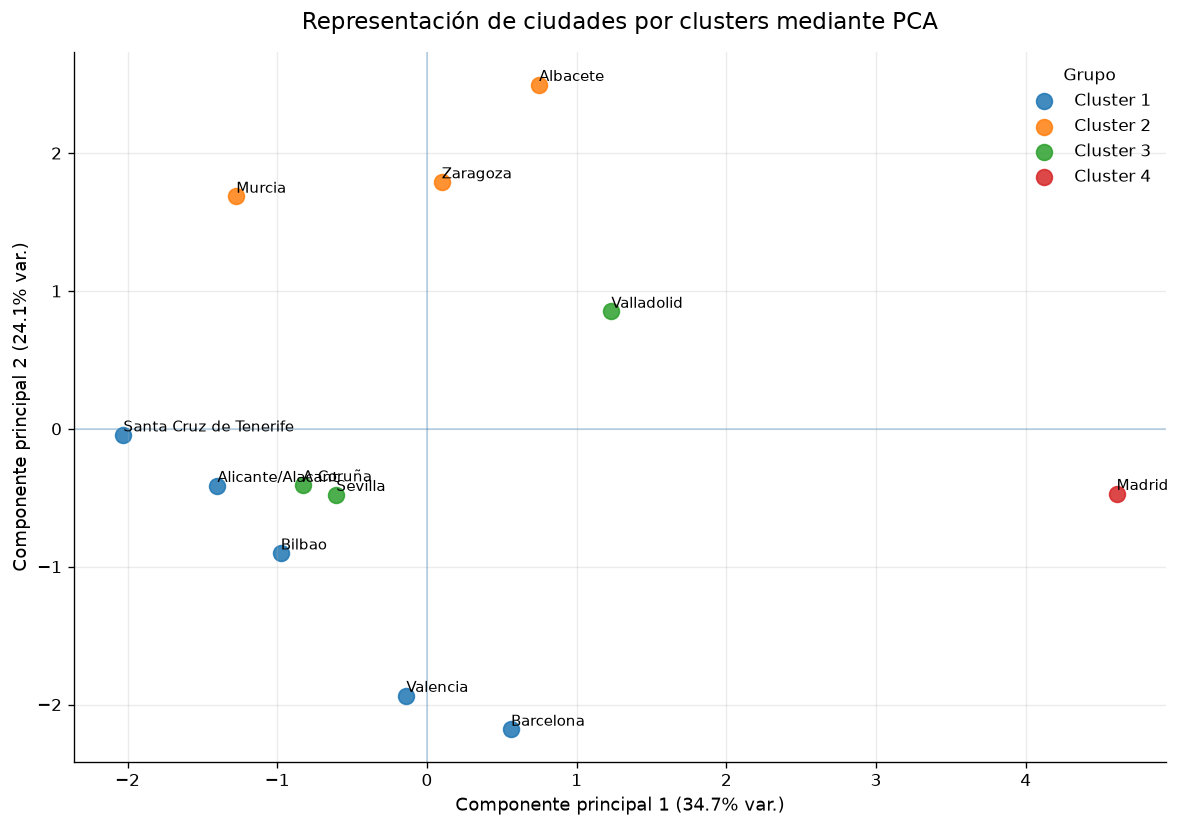

In [80]:
# =============================================================================
# 13. REPRESENTACIÓN DE CLUSTERS MEDIANTE PCA
# =============================================================================

# Se conservan las dos primeras componentes principales.
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)


# DataFrame auxiliar para representar las ciudades.
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_clusters["cluster"],
    col_ciudad: df_clusters[col_ciudad]
})


# Porcentaje de variabilidad original explicado por cada componente.
varianza_pc1 = (
    pca.explained_variance_ratio_[0] * 100
)

varianza_pc2 = (
    pca.explained_variance_ratio_[1] * 100
)


# -----------------------------------------------------------------------------
# Representación gráfica
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 7)
)

fig.patch.set_facecolor("white")


# Se representa cada cluster por separado.
for cluster in sorted(
    df_pca["cluster"].unique()
):

    df_cluster = df_pca[
        df_pca["cluster"] == cluster
    ]

    ax.scatter(
        df_cluster["PC1"],
        df_cluster["PC2"],
        s=90,
        label=f"Cluster {cluster}",
        alpha=0.85
    )


    # Se añade el nombre de cada ciudad junto a su punto.
    for _, fila in df_cluster.iterrows():

        ax.text(
            fila["PC1"],
            fila["PC2"],
            str(fila[col_ciudad]),
            fontsize=9,
            ha="left",
            va="bottom"
        )


# Líneas de referencia en el origen.
ax.axhline(
    0,
    linewidth=1,
    alpha=0.3
)

ax.axvline(
    0,
    linewidth=1,
    alpha=0.3
)


ax.set_title(
    "Representación de ciudades por clusters mediante PCA",
    fontsize=14,
    pad=14
)

ax.set_xlabel(
    f"Componente principal 1 ({varianza_pc1:.1f}% var.)",
    fontsize=11
)

ax.set_ylabel(
    f"Componente principal 2 ({varianza_pc2:.1f}% var.)",
    fontsize=11
)


ax.legend(
    title="Grupo",
    frameon=False
)

ax.grid(
    True,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()


plt.savefig(
    FOLDER_FIGS / "clusters_ciudades_pca.png",
    bbox_inches="tight",
    dpi=180,
    facecolor="white"
)

plt.show()

In [81]:
# =============================================================================
# 14. CONTRIBUCIÓN DE LAS VARIABLES A LAS COMPONENTES PRINCIPALES
# =============================================================================

cargas_pca = pd.DataFrame(
    pca.components_.T,
    index=columnas_numericas,
    columns=["PC1", "PC2"]
)

display(
    cargas_pca
    .sort_values(
        "PC1",
        key=abs,
        ascending=False
    )
)

,PC1,PC2
Distancia_Mar (km),0.525124,0.289410
Altitud (m),0.453711,0.362964
poblacion_mediana,0.452802,-0.354479
pib_mediano,0.420785,-0.393908
TPI_Factor_Cuenca,0.309048,-0.306057
Superficie (km²),0.167712,0.592582
Longitud,-0.108226,-0.106512
vehiculos_1000_hab_mediana,0.030839,-0.217970


Las dos primeras componentes principales explican conjuntamente el **58,8 % de la variabilidad total** de las características utilizadas, correspondiendo un 34,7 % a la primera componente y un 24,1 % a la segunda. Por tanto, la representación permite visualizar una parte importante de la estructura de los datos, aunque existe variabilidad adicional que no queda reflejada en el plano bidimensional.

El análisis de las cargas de las variables permite interpretar las características que determinan la posición de las ciudades. La **primera componente principal (PC1)** está determinada principalmente por la distancia al mar, la altitud, la población y el PIB, todas ellas con cargas positivas elevadas. Por tanto, esta componente combina características geográficas y socioeconómicas de las ciudades.

Esta primera componente permite explicar especialmente la posición de **Madrid**, que constituye individualmente el Cluster 4 y aparece claramente separada del resto hacia valores positivos de PC1. Su posición responde a la combinación de diferentes características que contribuyen en la misma dirección a esta componente, destacando su distancia al mar y altitud junto con sus elevados niveles de población y PIB. El resultado pone de manifiesto que Madrid presenta un perfil claramente diferenciado respecto al resto de ciudades consideradas.

La **segunda componente principal (PC2)** está dominada principalmente por la superficie, con una carga positiva de 0,593, seguida de la influencia positiva de la altitud y la distancia al mar. En sentido contrario aparecen el PIB y la población, con cargas negativas de -0,394 y -0,354, respectivamente. Esta componente establece, por tanto, un contraste entre determinadas características territoriales y la dimensión socioeconómica de las ciudades.

Este comportamiento permite comprender la posición del **Cluster 2**, formado por Murcia, Zaragoza y Albacete, que se sitúa en la zona superior del gráfico con valores positivos de PC2. En particular, Albacete presenta el valor más elevado en esta componente. En sentido contrario, Barcelona y Valencia se sitúan en la parte inferior de la representación, asociadas a valores negativos de PC2.

El **Cluster 3**, compuesto por A Coruña, Sevilla y Valladolid, ocupa una posición intermedia. A Coruña y Sevilla presentan una elevada proximidad en el plano formado por las dos primeras componentes, mientras que Valladolid se encuentra algo más desplazada hacia valores positivos de ambas componentes.

Por último, el **Cluster 1**, formado por Santa Cruz de Tenerife, Alicante/Alacant, Bilbao, Valencia y Barcelona, presenta una mayor dispersión en la representación bidimensional. Destaca especialmente la proximidad entre Barcelona y Valencia, mientras que las restantes ciudades se concentran principalmente en la zona negativa de PC1.